In [1]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from constant import EXPS_PATH

In [204]:
def get_max_auc_val(
    res_df=lifesnaps_results,
    dataset='lifesnaps',
    mode='clip',
    stats=False,
):
    max_auc_all_arr = res_df[
        (res_df['dataset'] == dataset)
        & (res_df['exp'] == 'run')
        & (res_df['norm_type'] == 'global')
        & (res_df['scaler'] == 'quantile')
        & (res_df['seq_enc'] == 'transformer')
        & (res_df['tab_enc'] == 'resnet')
        & (res_df['mode'] == mode)
    ]
    # for each combination of fold and seed, get the best result in terms of max_auc_all
    max_auc_all_arr = max_auc_all_arr.groupby(['fold', 'seed'])
    max_auc_all_arr = max_auc_all_arr['max_auc_all'].max()
    max_auc_all_arr = max_auc_all_arr.reset_index()
    # compute average and std of the best results
    max_auc_all_arr = max_auc_all_arr['max_auc_all']
    if stats:
        auc_mean, auc_std = max_auc_all_arr.mean(), max_auc_all_arr.std()
        return auc_mean, auc_std
    else:
        return max_auc_all_arr

In [208]:
tree_based_results = pd.read_csv('results.csv')

In [211]:
lifesnaps_tree = tree_based_results[tree_based_results['dataset'] == 'lifesnaps']
lifesnaps_rf = lifesnaps_tree[lifesnaps_tree['clf'] == 'random forest']
lifesnaps_xgb = lifesnaps_tree[lifesnaps_tree['clf'] == 'xgboost']

In [213]:
pmdata_tree = tree_based_results[tree_based_results['dataset'] == 'pmdata']
pmdata_rf = pmdata_tree[pmdata_tree['clf'] == 'random forest']
pmdata_xgb = pmdata_tree[pmdata_tree['clf'] == 'xgboost']

In [229]:
lifesnaps_dict = {}
for mode in ['sup', 'clip', 'simclr', 'byol', 'leaves']:
    aucs = get_max_auc_val(
        res_df=lifesnaps_results,
        dataset='lifesnaps',
        mode=mode,
    )
    lifesnaps_dict[mode] = np.array(aucs)
lifesnaps_dict['xgboost'] = lifesnaps_xgb['auc'].values
lifesnaps_dict['random forest'] = lifesnaps_rf['auc'].values

In [230]:
pmdata_dict = {}
for mode in ['sup', 'clip', 'simclr', 'byol', 'leaves']:
    aucs = get_max_auc_val(
        res_df=pmdata_results,
        dataset='pmdata',
        mode=mode,
    )
    pmdata_dict[mode] = np.array(aucs)
pmdata_dict['xgboost'] = pmdata_xgb['auc'].values
pmdata_dict['random forest'] = pmdata_rf['auc'].values

In [231]:
lifesnaps_dict

{'sup': array([0.63900862, 0.69181034, 0.71012931, 0.56681034, 0.74353448,
        0.83728448, 0.77478448, 0.76077586, 0.57083333, 0.56041667,
        0.60208333, 0.6       , 0.76041667, 0.625     , 0.7125    ,
        0.68541667, 0.71041667, 0.63958333, 0.62916667, 0.61666667]),
 'clip': array([0.7262931 , 0.72306034, 0.70905172, 0.69935345, 0.74030172,
        0.7887931 , 0.7887931 , 0.7887931 , 0.67083333, 0.66458333,
        0.68125   , 0.74375   , 0.77291667, 0.74375   , 0.79375   ,
        0.73125   , 0.68125   , 0.72916667, 0.69583333, 0.61666667]),
 'simclr': array([0.6950431 , 0.70905172, 0.71228448, 0.72952586, 0.76077586,
        0.75431034, 0.76077586, 0.77478448, 0.7       , 0.63333333,
        0.63125   , 0.72916667, 0.71458333, 0.68333333, 0.7       ,
        0.74583333, 0.66458333, 0.66458333, 0.66458333, 0.6375    ]),
 'byol': array([0.68103448, 0.73706897, 0.71228448, 0.64978448, 0.72306034,
        0.79202586, 0.6950431 , 0.74353448, 0.57708333, 0.58958333,
        0

In [232]:
pmdata_dict

{'sup': array([0.80784417, 0.80387527, 0.81488643, 0.8174306 , 0.82646573,
        0.85487201, 0.81771263, 0.81754748, 0.80859213, 0.81987578,
        0.80289855, 0.81604555, 0.79347826, 0.7820911 , 0.79006211,
        0.78913043, 0.79228414, 0.79604001, 0.80865483, 0.79953052]),
 'clip': array([0.8333062 , 0.83096556, 0.81561915, 0.7979321 , 0.83905863,
        0.82093311, 0.81193229, 0.8104872 , 0.84068323, 0.82028986,
        0.81490683, 0.82287785, 0.78467909, 0.78012422, 0.80921325,
        0.79440994, 0.81071647, 0.78338436, 0.78730353, 0.8183711 ]),
 'simclr': array([0.74411789, 0.7387039 , 0.74141089, 0.75586176, 0.77246078,
        0.80239472, 0.77254335, 0.7538398 , 0.7752588 , 0.72795031,
        0.76231884, 0.74078675, 0.71118012, 0.68074534, 0.71231884,
        0.71656315, 0.70465401, 0.72308634, 0.73302715, 0.72867932]),
 'byol': array([0.77662216, 0.78655459, 0.73292355, 0.7554954 , 0.78257638,
        0.7538398 , 0.78104872, 0.75247729, 0.74378882, 0.73819876,
        0

Text(0.5, 1.0, 'Lifesnaps')

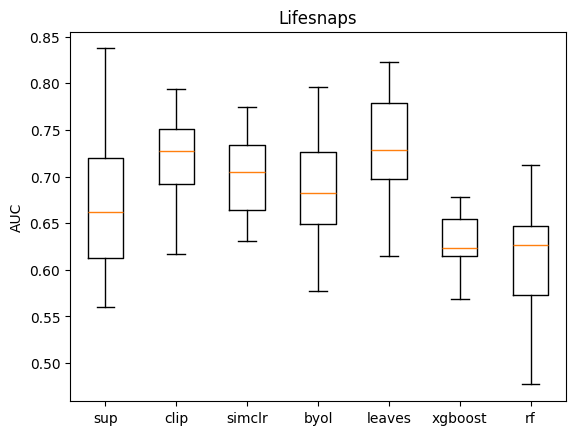

In [235]:
# box plot for lifesnaps

fig, ax = plt.subplots()
ax.boxplot([
    lifesnaps_dict['sup'],
    lifesnaps_dict['clip'],
    lifesnaps_dict['simclr'],
    lifesnaps_dict['byol'],
    lifesnaps_dict['leaves'],
    lifesnaps_dict['xgboost'],
    lifesnaps_dict['random forest'],
])
ax.set_xticklabels([
    'sup', 'clip', 'simclr', 'byol', 'leaves', 'xgboost', 'rf',
])
ax.set_ylabel('AUC')
ax.set_title('Lifesnaps')

Text(0.5, 1.0, 'PMData')

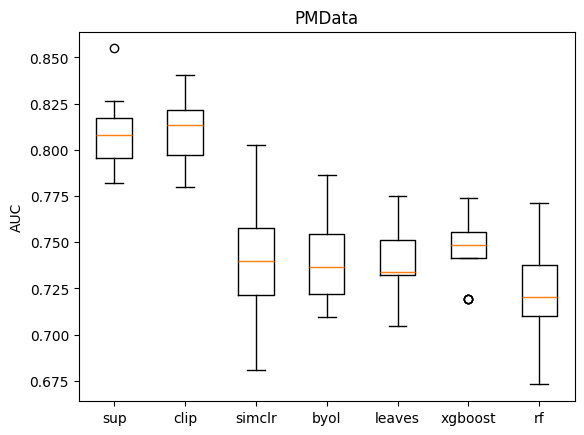

In [236]:
# box plot for pmdata

fig, ax = plt.subplots()
ax.boxplot([
    pmdata_dict['sup'],
    pmdata_dict['clip'],
    pmdata_dict['simclr'],
    pmdata_dict['byol'],
    pmdata_dict['leaves'],
    pmdata_dict['xgboost'],
    pmdata_dict['random forest'],
])
ax.set_xticklabels([
    'sup', 'clip', 'simclr', 'byol', 'leaves', 'xgboost', 'rf',
])
ax.set_ylabel('AUC')
ax.set_title('PMData')

In [237]:
from scipy.stats import tukey_hsd

In [243]:
lifesnaps_res = tukey_hsd(
        lifesnaps_dict['sup'],
        lifesnaps_dict['clip'],
        lifesnaps_dict['simclr'],
        lifesnaps_dict['byol'],
        lifesnaps_dict['leaves'],
        lifesnaps_dict['xgboost'],
        lifesnaps_dict['random forest'],
)

In [245]:
print(lifesnaps_res)

Tukey's HSD Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)     -0.053     0.072    -0.108     0.002
 (0 - 2)     -0.031     0.612    -0.087     0.024
 (0 - 3)     -0.014     0.989    -0.069     0.041
 (0 - 4)     -0.060     0.023    -0.115    -0.005
 (0 - 5)      0.044     0.210    -0.011     0.099
 (0 - 6)      0.060     0.023     0.005     0.115
 (1 - 0)      0.053     0.072    -0.002     0.108
 (1 - 2)      0.021     0.910    -0.034     0.076
 (1 - 3)      0.039     0.350    -0.016     0.094
 (1 - 4)     -0.008     1.000    -0.063     0.048
 (1 - 5)      0.097     0.000     0.042     0.152
 (1 - 6)      0.113     0.000     0.058     0.168
 (2 - 0)      0.031     0.612    -0.024     0.087
 (2 - 1)     -0.021     0.910    -0.076     0.034
 (2 - 3)      0.018     0.961    -0.037     0.073
 (2 - 4)     -0.029     0.707    -0.084     0.026
 (2 - 5)      0.075     0.001     0.020     0.131
 (2 - 6)      0.092     0.000   

In [246]:
pmdata_res = tukey_hsd(
        pmdata_dict['sup'],
        pmdata_dict['clip'],
        pmdata_dict['simclr'],
        pmdata_dict['byol'],
        pmdata_dict['leaves'],
        pmdata_dict['xgboost'],
        pmdata_dict['random forest'],
)

In [247]:
print(pmdata_res)

Tukey's HSD Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)     -0.003     0.999    -0.024     0.018
 (0 - 2)      0.068     0.000     0.047     0.089
 (0 - 3)      0.067     0.000     0.045     0.088
 (0 - 4)      0.068     0.000     0.047     0.089
 (0 - 5)      0.060     0.000     0.039     0.081
 (0 - 6)      0.084     0.000     0.063     0.105
 (1 - 0)      0.003     0.999    -0.018     0.024
 (1 - 2)      0.071     0.000     0.050     0.093
 (1 - 3)      0.070     0.000     0.049     0.091
 (1 - 4)      0.071     0.000     0.050     0.092
 (1 - 5)      0.064     0.000     0.043     0.085
 (1 - 6)      0.088     0.000     0.067     0.109
 (2 - 0)     -0.068     0.000    -0.089    -0.047
 (2 - 1)     -0.071     0.000    -0.093    -0.050
 (2 - 3)     -0.002     1.000    -0.023     0.019
 (2 - 4)     -0.000     1.000    -0.021     0.021
 (2 - 5)     -0.008     0.925    -0.029     0.013
 (2 - 6)      0.016     0.257   

In [249]:
lifesnaps_dict

{'sup': array([0.63900862, 0.69181034, 0.71012931, 0.56681034, 0.74353448,
        0.83728448, 0.77478448, 0.76077586, 0.57083333, 0.56041667,
        0.60208333, 0.6       , 0.76041667, 0.625     , 0.7125    ,
        0.68541667, 0.71041667, 0.63958333, 0.62916667, 0.61666667]),
 'clip': array([0.7262931 , 0.72306034, 0.70905172, 0.69935345, 0.74030172,
        0.7887931 , 0.7887931 , 0.7887931 , 0.67083333, 0.66458333,
        0.68125   , 0.74375   , 0.77291667, 0.74375   , 0.79375   ,
        0.73125   , 0.68125   , 0.72916667, 0.69583333, 0.61666667]),
 'simclr': array([0.6950431 , 0.70905172, 0.71228448, 0.72952586, 0.76077586,
        0.75431034, 0.76077586, 0.77478448, 0.7       , 0.63333333,
        0.63125   , 0.72916667, 0.71458333, 0.68333333, 0.7       ,
        0.74583333, 0.66458333, 0.66458333, 0.66458333, 0.6375    ]),
 'byol': array([0.68103448, 0.73706897, 0.71228448, 0.64978448, 0.72306034,
        0.79202586, 0.6950431 , 0.74353448, 0.57708333, 0.58958333,
        0

In [256]:
for key, value in lifesnaps_dict.items():
    # percentage with 2 decimal places
    print(
        'lifesnaps', 
        key, 
        np.round(value.mean() * 100, 2), 
        np.round(value.std() * 100, 2),
    )

lifesnaps sup 67.18 7.65
lifesnaps clip 72.45 4.7
lifesnaps simclr 70.33 4.31
lifesnaps byol 68.55 6.08
lifesnaps leaves 73.2 5.65
lifesnaps xgboost 62.78 3.7
lifesnaps random forest 61.16 6.61


In [257]:
for key, value in pmdata_dict.items():
    print(
        'pmdata', 
        key, 
        np.round(value.mean() * 100, 2), 
        np.round(value.std() * 100, 2),
    )

pmdata sup 80.8 1.6
pmdata clip 81.14 1.79
pmdata simclr 73.99 2.8
pmdata byol 74.14 2.45
pmdata leaves 74.03 1.81
pmdata xgboost 74.77 1.79
pmdata random forest 72.38 2.59
